# 02 — Is the sector a *cause*? The energy-matched intervention

The criterion in notebook 01 says *where* a duality's fixed point matters. It presupposes something
more basic: that the **sector** — here, the topological winding number of a superfluid's phase — is a
cause of what the fluid does, not merely a label of its microstate. This notebook presents the test
of that presupposition, in the interventionist sense of Woodward and Pearl: hold everything else fixed,
change only the sector, and see whether the outcome changes.

**The system.** A projected Gross–Pitaevskii classical field: a standard model of a two-dimensional
Bose gas (a superfluid film), on a periodic $64\times64$ box, equilibrated from three independent
initial states ("bases": energy per particle $e=0.60$ and $e=0.90$ with two seeds).

**The intervention (pre-registered).** From each equilibrated base, three arms continue:

| arm | what is added | what is held fixed |
|---|---|---|
| **V** (vortex) | four free vortex–antivortex pairs — new topology | particle number, momentum, **total energy** |
| **P** (phonon) | the *same* energy, as sound waves — no new topology | particle number, momentum, total energy |
| **0** (control) | nothing | — |

If the sector is only a label, V and P should look alike: same energy, same everything else.

## What is live here and what is replotted

- **Live (seconds):** §1 — the mathematical prerequisite, on a small synthetic phase field: the
  winding number is read correctly by a loop sum, and a bound vortex pair is invisible from any
  enclosing loop. These are the statements proved in Lean in `lean/ContinuumWinding.lean` and
  `lean/ScaleResolvedWinding.lean`.
- **Replotted from archived results:** §2–§4. The simulations themselves take hours of CPU per arm and
  are *not* rerun here. The per-block observables of every arm are archived in
  `data/results/intervention_r2/` (copied unmodified from the origin repository,
  SocrateAI-Scientific-QuantumFluids, `data/generated/pgpe/r2/`), and every number below is computed
  from those files in this notebook.
- **Round 4 (§5)** is read from `data/results/torus_r4/r4_verdicts.json`, the archived verdict file.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import sct_style as S
S.apply()
R2 = S.DATA / "results" / "intervention_r2"
R4 = S.DATA / "results" / "torus_r4"

## 1. Live: reading a sector with a loop sum, and why a bound pair is invisible from outside

Place a vortex (winding $+1$) and an antivortex ($-1$) in a phase field $\theta(x,y)$, add a smooth
random "phonon" perturbation, and sum the principal-branch phase differences
$\sum \operatorname{wrap}(\theta_{i+1}-\theta_i)$ around a closed loop. Divided by $2\pi$ it is always an
integer — the **net winding enclosed**:

- a loop around the vortex alone reads $+1$;
- a loop around both reads $0$ — the pair is invisible from any scale that encloses it
  (`ScaleResolvedWinding`: the winding at scale $R$ is the net charge inside $R$);
- the smooth perturbation changes nothing, as long as it causes no phase slip
  (`TopologicalProtection`: winding is conserved by every continuous evolution without a slip).

In [2]:
N = 96
y, x = np.mgrid[0:N, 0:N].astype(float)
v, av = (36.0, 48.0), (60.0, 48.0)
theta = np.arctan2(y - v[1], x - v[0]) - np.arctan2(y - av[1], x - av[0])

rng = np.random.default_rng(1)
k = np.fft.fftfreq(N)
KX, KY = np.meshgrid(k, k)
smooth = np.real(np.fft.ifft2(np.fft.fft2(rng.normal(size=(N, N))) * np.exp(-(KX**2 + KY**2) / (2 * 0.03**2))))
smooth *= 1.2 / np.abs(smooth).max()          # phonon-like perturbation, amplitude 1.2 rad
theta_p = theta + smooth

def wrap(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def loop_winding(th, x0, x1, y0, y1):
    # counter-clockwise: along the bottom edge, up the right edge, back along the top, down the left
    path = ([(i, y0) for i in range(x0, x1)] + [(x1, j) for j in range(y0, y1)] +
            [(i, y1) for i in range(x1, x0, -1)] + [(x0, j) for j in range(y1, y0, -1)])
    vals = np.array([th[j, i] for i, j in path] + [th[path[0][1], path[0][0]]])
    return np.sum(wrap(np.diff(vals))) / (2 * np.pi)

loops = {"around the vortex only": (28, 44, 40, 56),
         "around both (the bound pair)": (20, 76, 32, 64),
         "around neither": (70, 90, 10, 30)}
print(f"{'loop':32} {'unperturbed':>12} {'with phonons':>13}")
for name, (x0, x1, y0, y1) in loops.items():
    print(f"{name:32} {loop_winding(theta, x0, x1, y0, y1):12.6f} {loop_winding(theta_p, x0, x1, y0, y1):13.6f}")

loop                              unperturbed  with phonons
around the vortex only               1.000000      1.000000
around both (the bound pair)        -0.000000      0.000000
around neither                      -0.000000     -0.000000


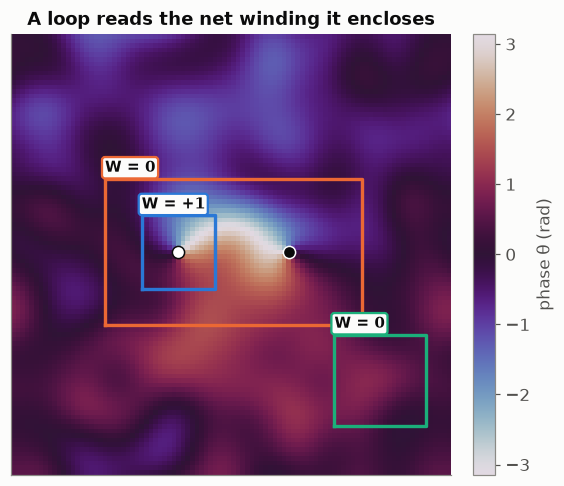

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(wrap(theta_p), cmap="twilight", origin="lower", vmin=-np.pi, vmax=np.pi)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label("phase θ (rad)")
cols = [S.BLUE, S.ORANGE, S.AQUA]
for (name, (x0, x1, y0, y1)), c in zip(loops.items(), cols):
    w = round(loop_winding(theta_p, x0, x1, y0, y1))
    ax.plot([x0, x0, x1, x1, x0], [y0, y1, y1, y0, y0], color=c, lw=2.2)
    ax.text(x0, y1 + 1.5, f"W = {w:+d}" if w else "W = 0", color=S.INK, fontsize=10, fontweight="bold",
            bbox=dict(fc=S.SURFACE, ec=c, lw=1.5, boxstyle="round,pad=0.2"))
ax.plot(*v, "o", color="white", mec=S.INK, ms=8); ax.plot(*av, "o", color=S.INK, mec="white", ms=8)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title("A loop reads the net winding it encloses")
S.save(fig, "02_winding_loops"); plt.show()

The loop around the vortex alone reads $+1$; the loop around the pair reads $0$; the smooth
perturbation, 1.2 rad in amplitude, changes none of them. The sector is a robust, integer-valued
quantity that a smooth disturbance cannot touch — which is what makes it something one can intervene
on.

## 2. The archived intervention: condensate fraction, block by block

Each arm's run is split into blocks of 100 time units; each block records the condensate fraction,
temperature, vortex count, and the coherence exponent $\eta$. The pre-registered comparison window is
$t\in[100,300)$ (blocks starting at $t=100, 200$).

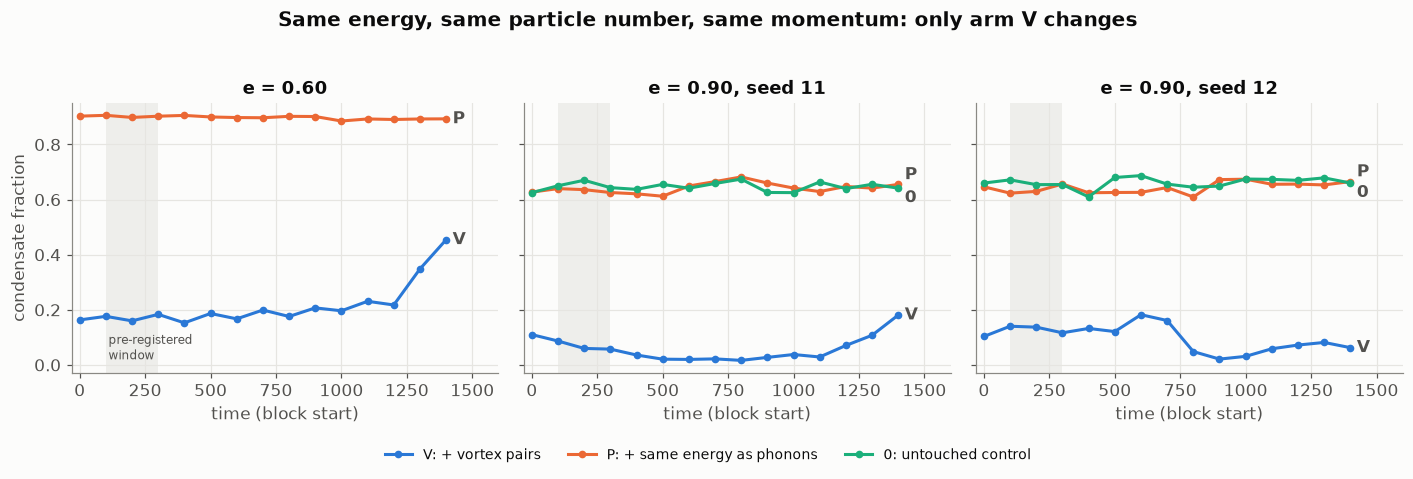

At e = 0.60 there is no archived control arm 0 (the pre-registration compared V against P only).


In [4]:
BASES = [("e0.60_s11_t4000", "e = 0.60"), ("e0.90_s11_t4000", "e = 0.90, seed 11"), ("e0.90_s12_t4000", "e = 0.90, seed 12")]
ARMS = [("V", "V: + vortex pairs", S.BLUE), ("P", "P: + same energy as phonons", S.ORANGE), ("0", "0: untouched control", S.AQUA)]

def load(base, arm):
    f = R2 / f"I_{base}_{arm}.json"
    return json.loads(f.read_text()) if f.exists() else None

def early(d):
    bl = [b for b in d["blocks"] if b["t0"] in (100.0, 200.0)]
    return {k: float(np.mean([b[k] for b in bl])) for k in ("cond", "T", "eta", "n_v")}

fig, axs = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, (base, label) in zip(axs, BASES):
    for arm, alab, c in ARMS:
        d = load(base, arm)
        if d is None:
            continue
        t = [b["t0"] for b in d["blocks"]]; cnd = [b["cond"] for b in d["blocks"]]
        ax.plot(t, cnd, "-o", color=c, ms=4, label=alab)
        dy = {"V": 0.0, "P": 0.035, "0": -0.035}[arm] if base != BASES[0][0] else 0.0
        ax.text(t[-1] + 25, cnd[-1] + dy, arm, color=S.INK_2, va="center", fontweight="bold")
    ax.axvspan(100, 300, color=S.GRID, alpha=0.6, lw=0)
    ax.set_title(label); ax.set_xlabel("time (block start)"); ax.set_xlim(-30, 1600)
axs[0].set_ylabel("condensate fraction"); axs[0].text(110, 0.02, "pre-registered\nwindow", fontsize=8, color=S.INK_2)
h, l = axs[1].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("Same energy, same particle number, same momentum: only arm V changes", fontweight="bold", y=1.03)
fig.tight_layout(); S.save(fig, "02_condensate_by_arm"); plt.show()
print("At e = 0.60 there is no archived control arm 0 (the pre-registration compared V against P only).")

## 3. The headline numbers, computed from the archived blocks

The pre-registered predictions were: **I1** the condensate is lower in V by at least 0.15; **I2** the
thermometer reads V and P within 5%; **I4** the coherence exponent $\eta$ is at least $1.5\times$
larger in V. The *effect per unit energy* compares each arm with the untouched control, using — as the
paper does — the control's whole-run mean as its baseline. (Recomputed here, the η ratios against the control
come out as ×10.8 and ×1.01 at $e=0.90$ seed 11, where the paper quotes ×10.9 and ×0.99 — the paper
rounds from a slightly different η averaging. The condensate numbers match the paper exactly.)

In [5]:
rows = []
for base, label in BASES:
    V, P = early(load(base, "V")), early(load(base, "P"))
    d0 = load(base, "0")
    r = {"base": label, "I1 cond gap (P−V)": P["cond"] - V["cond"], "I2 |T_V−T_P|/T_P": abs(V["T"] - P["T"]) / P["T"],
         "T_V < T_P": V["T"] < P["T"], "I4 η_V/η_P": V["eta"] / P["eta"]}
    if d0 is not None:
        c0, e0 = d0["whole"]["cond"], d0["whole"]["eta"]
        r.update({"Δcond V−0": V["cond"] - c0, "Δcond P−0": P["cond"] - c0, "η V/0": V["eta"] / e0, "η P/0": P["eta"] / e0})
    rows.append(r)

for r in rows:
    print(r["base"])
    print(f"  I1 condensate gap P−V = {r['I1 cond gap (P−V)']:.3f}   ({'PASS' if r['I1 cond gap (P−V)'] >= 0.15 else 'fail'}, threshold 0.15)")
    print(f"  I4 η ratio V/P        = {r['I4 η_V/η_P']:.1f}     ({'PASS' if r['I4 η_V/η_P'] >= 1.5 else 'fail'}, threshold 1.5)")
    print(f"  I2 thermometer        = {r['I2 |T_V−T_P|/T_P']:.3f}   ({'PASS' if r['I2 |T_V−T_P|/T_P'] <= 0.05 else 'FAIL'}, threshold 0.05; T_V < T_P: {r['T_V < T_P']})")
    if "Δcond V−0" in r:
        print(f"  vs control: Δcond V = {r['Δcond V−0']:+.3f}, P = {r['Δcond P−0']:+.3f};  η ×{r['η V/0']:.1f} in V, ×{r['η P/0']:.2f} in P"
              f"  → same energy as topology moves the condensate {abs(r['Δcond V−0'] / r['Δcond P−0']):.0f}× more")

e = 0.60
  I1 condensate gap P−V = 0.734   (PASS, threshold 0.15)
  I4 η ratio V/P        = 43.7     (PASS, threshold 1.5)
  I2 thermometer        = 0.161   (FAIL, threshold 0.05; T_V < T_P: True)
e = 0.90, seed 11
  I1 condensate gap P−V = 0.565   (PASS, threshold 0.15)
  I4 η ratio V/P        = 10.7     (PASS, threshold 1.5)
  I2 thermometer        = 0.055   (FAIL, threshold 0.05; T_V < T_P: True)
  vs control: Δcond V = -0.574, P = -0.009;  η ×10.8 in V, ×1.01 in P  → same energy as topology moves the condensate 62× more
e = 0.90, seed 12
  I1 condensate gap P−V = 0.488   (PASS, threshold 0.15)
  I4 η ratio V/P        = 8.6     (PASS, threshold 1.5)
  I2 thermometer        = 0.092   (FAIL, threshold 0.05; T_V < T_P: True)
  vs control: Δcond V = -0.523, P = -0.035;  η ×10.4 in V, ×1.20 in P  → same energy as topology moves the condensate 15× more


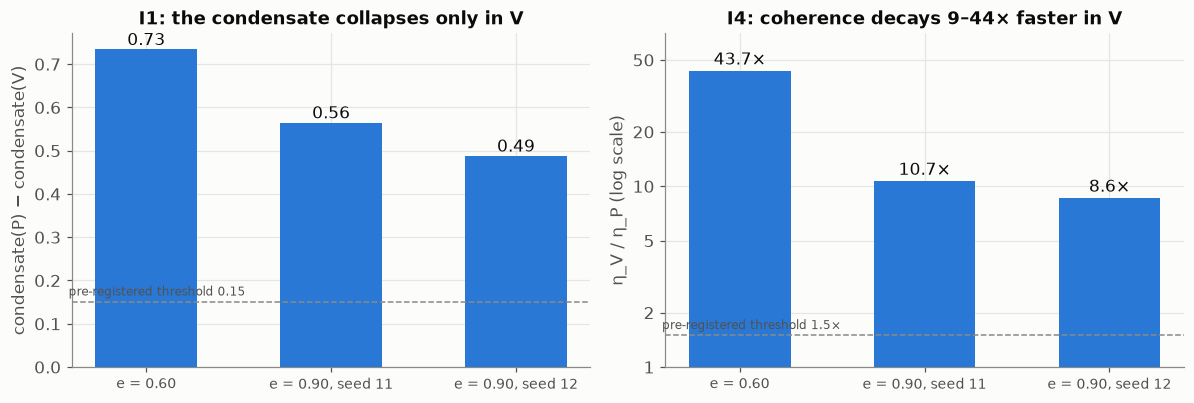

In [6]:
labels = [r["base"] for r in rows]
x = np.arange(len(rows))
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axs[0]
gap = [r["I1 cond gap (P−V)"] for r in rows]
bars = ax.bar(x, gap, width=0.55, color=S.BLUE, zorder=3)
ax.axhline(0.15, color=S.MUTED, ls="--", lw=1, zorder=4); ax.text(-0.42, 0.165, "pre-registered threshold 0.15", fontsize=8, color=S.INK_2)
for xi, g in zip(x, gap): ax.text(xi, g + 0.01, f"{g:.2f}", ha="center", color=S.INK)
ax.set_xticks(x, labels, fontsize=9); ax.set_ylabel("condensate(P) − condensate(V)")
ax.set_title("I1: the condensate collapses only in V")
ax = axs[1]
rat = [r["I4 η_V/η_P"] for r in rows]
ax.bar(x, rat, width=0.55, color=S.BLUE, zorder=3)
ax.axhline(1.5, color=S.MUTED, ls="--", lw=1, zorder=4); ax.text(-0.42, 1.62, "pre-registered threshold 1.5×", fontsize=8, color=S.INK_2)
for xi, g in zip(x, rat): ax.text(xi, g * 1.08, f"{g:.1f}×", ha="center", color=S.INK)
ax.set_yscale("log"); S.plain_log_ticks(ax.yaxis, [1, 2, 5, 10, 20, 50]); ax.set_ylim(1, 70)
ax.set_xticks(x, labels, fontsize=9); ax.set_ylabel("η_V / η_P (log scale)")
ax.set_title("I4: coherence decays 9–44× faster in V")
fig.tight_layout(); S.save(fig, "02_headline_I1_I4"); plt.show()

## 4. The pre-registered criterion that failed — reported, not hidden

The composite causal claim was pre-registered as "at fixed $E$, $N$, $P$ **and measured temperature**,
the topology sets condensate and coherence", requiring I1, I2 and I4 on all three bases. **I2 fails on
all three:** the thermometer reads arm V *colder* than arm P, by more than the 1.5–3.3% the pre-data
amendment allowed for. The composite claim, as pre-registered, is therefore **not made**.

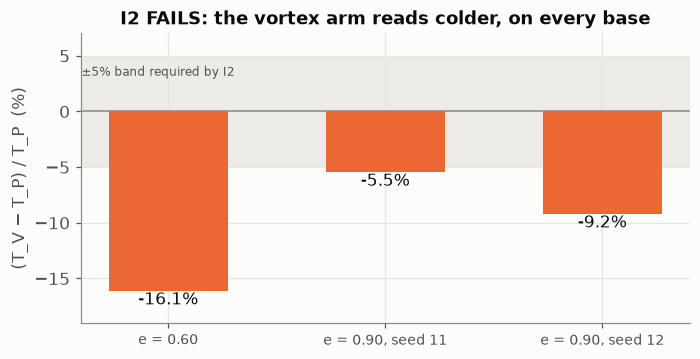

In [7]:
rel = [(early(load(b, "V"))["T"] - early(load(b, "P"))["T"]) / early(load(b, "P"))["T"] * 100 for b, _ in BASES]
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(x, rel, width=0.55, color=S.ORANGE, zorder=3)
ax.axhspan(-5, 5, color=S.GRID, alpha=0.7, lw=0, zorder=1); ax.text(-0.4, 3.2, "±5% band required by I2", fontsize=8, color=S.INK_2)
for xi, g in zip(x, rel): ax.text(xi, g - 1.2, f"{g:.1f}%", ha="center", color=S.INK)
ax.axhline(0, color=S.MUTED, lw=1)
ax.set_xticks(x, labels, fontsize=9); ax.set_ylabel("(T_V − T_P) / T_P  (%)"); ax.set_ylim(-19, 7)
ax.set_title("I2 FAILS: the vortex arm reads colder, on every base")
fig.tight_layout(); S.save(fig, "02_thermometer_failure"); plt.show()

**What survives, and how.** The failure has the *wrong sign* to explain the effect: a colder gas
carries **more** condensate, yet arm V carries five to ten times *less*. With total energy conserved to
$2\times10^{-7}$, the bath's lost heat went into the vortex system. The post-hoc reading — the
injected vortex configuration is a subsystem with its own temperature, weakly coupled to the phonon
bath (Onsager's picture) — is developed in the companion work and its combinatorial core is
machine-checked in `lean/SectorTemperature.lean` (the inverse temperature of a state mixing two sectors
is a *mediant* of the sector inverse temperatures, not their average). That reading is **post hoc** and
labelled as such everywhere it appears; the pre-registered composite claim remains *not made*.

## 5. Round 4: a density map cannot see the sector — only the vortex cores

A torus test transplants the question to wave dark matter: can a density observable read a net
circulation (the sector) or only local vortex cores? Arms: **V3** (an imposed winding-3 current, no
extra cores), **P16** (sixteen injected pairs, no net winding), **V3P16** (both), against control **0**.

base              B1 sector alone   B2 pairs  B4 sector on top of pairs
e = 0.60                     0.3%       118%                      -1.1%
e = 0.90, s11                3.6%        25%                       2.6%
e = 0.90, s12                2.6%        21%                       3.7%
verdicts: {'B1_all': True, 'B2_all': False, 'B4_all': True, 'B3_all_e090': True}


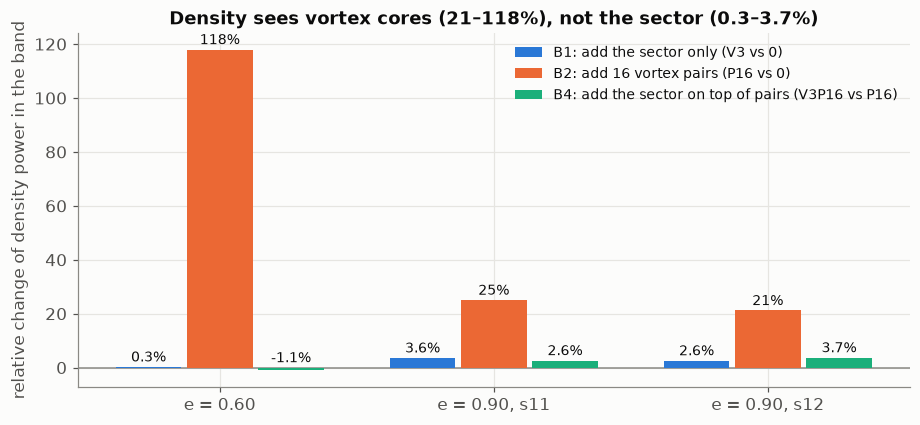

In [8]:
r4 = json.loads((R4 / "r4_verdicts.json").read_text())
names = [("e0.60_s11_t4000", "e = 0.60"), ("e0.90_s11_t4000", "e = 0.90, s11"), ("e0.90_s12_t4000", "e = 0.90, s12")]
B1 = [100 * r4[b]["B1_ratio"] for b, _ in names]
B2 = [100 * r4[b]["B2_ratio"] for b, _ in names]
B4 = [100 * r4[b]["B4_ratio"] for b, _ in names]
print(f"{'base':16} {'B1 sector alone':>16} {'B2 pairs':>10} {'B4 sector on top of pairs':>26}")
for (b, lab), a, c, d in zip(names, B1, B2, B4):
    print(f"{lab:16} {a:15.1f}% {c:9.0f}% {d:25.1f}%")
print("verdicts:", {k: r4[k] for k in ("B1_all", "B2_all", "B4_all", "B3_all_e090")})

fig, ax = plt.subplots(figsize=(8.5, 4))
w = 0.26; xx = np.arange(3)
for off, vals, c, lab in ((-w, B1, S.BLUE, "B1: add the sector only (V3 vs 0)"), (0, B2, S.ORANGE, "B2: add 16 vortex pairs (P16 vs 0)"),
                          (w, B4, S.AQUA, "B4: add the sector on top of pairs (V3P16 vs P16)")):
    ax.bar(xx + off, vals, width=w - 0.02, color=c, label=lab, zorder=3)
    for xi, v_ in zip(xx + off, vals):
        ax.text(xi, max(v_, 0) + 2, f"{v_:.0f}%" if abs(v_) >= 10 else f"{v_:.1f}%", ha="center", fontsize=9, color=S.INK)
ax.axhline(0, color=S.MUTED, lw=1)
ax.set_xticks(xx, [l for _, l in names]); ax.set_ylabel("relative change of density power in the band")
ax.set_title("Density sees vortex cores (21–118%), not the sector (0.3–3.7%)")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout(); S.save(fig, "02_round4_density_blind"); plt.show()

B1 and B4 pass everywhere: the imposed sector moves the density observable by 0.3–3.7%, with or without
pairs present. B2 — the pairs are *visible* in density — has the right direction and magnitude
everywhere but misses its pre-set 30% threshold at $e=0.90$ (25% and 21%) and is recorded as **failed as
written**; a later recalibration per injected vortex (not reproduced here) is documented in the origin
repository's `PGPE_R4_RESULTS.md`. The sector is read by phase and momentum observables, not by density.

## Summary

| claim | status here | source |
|---|---|---|
| a loop sum reads the enclosed winding; a bound pair is invisible from outside | **recomputed live** | §1 |
| same energy as topology collapses the condensate (I1), coherence (I4) | **pass on all bases**, computed from archived blocks | §2–3 |
| the thermometer agrees across arms (I2) | **FAILED on all bases** — composite claim not made | §4 |
| density is blind to the sector, sensitive to cores (round 4, B1/B4) | **pass**; B2 threshold failed as written | §5 |

The interventional test supports the presupposition the criterion needs — a sector, once identified,
is a lever, not only a label — while the one pre-registered clause that failed is carried in the record
at the same weight as the ones that passed.